# AI Don't Know Workshop 2: Data Analytics and Visualisation

**22 July · 3:00–5:00 PM · Alson & Murugan**

## Learning outcomes

By the end of this workshop, you will be able to create and read a pandas DataFrame, select and filter data, calculate simple summaries, create a calculated column, choose a suitable chart, make bar/line/scatter plots, try a seaborn alternative, and explain one insight in plain English.

## Start Here — Slides 1–3

Use this notebook alongside the slides. Run each live-demo cell when the speaker reaches it, then read the `Output:` line immediately below.

Our teaching loop is:

**Question → Data → Code → Output/Chart → Insight**

During activities, complete only the guided blanks. Try a hint before asking for the full solution.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

print(f"Workshop setup ready — Python {sys.version_info.major}.{sys.version_info.minor}")

Workshop setup ready — Python 3.13


Output: The setup confirms the Python version, imports all four workshop libraries, and applies projector-readable chart defaults.

## Ask a Data Question — Slides 4–6

Data analytics starts with a question. We choose the values that can act as evidence, use code to calculate or draw a chart, and explain the result in plain English.

Today's questions include: Who improved the most? Which food item received the most orders? Does studying more seem linked to higher quiz scores?

## pandas: Student Scores — Slides 7–12

pandas is our main tool for labelled tables. A **DataFrame** is a table with rows and named columns. Every demo below answers a visible question.

In [2]:
student_data = {
    "Name": ["Alex", "Bella", "Chen", "Deepa", "Ethan"],
    "Class": ["A", "A", "B", "B", "A"],
    "Quiz1": [72, 85, 60, 90, 55],
    "Quiz2": [78, 88, 70, 92, 65]
}
students = pd.DataFrame(student_data)
students

,Name,Class,Quiz1,Quiz2
0,Alex,A,72,78
1,Bella,A,85,88
2,Chen,B,60,70
3,Deepa,B,90,92
4,Ethan,A,55,65


Output: A DataFrame with five students and four columns: Name, Class, Quiz1, and Quiz2.

In [3]:
students.head()

,Name,Class,Quiz1,Quiz2
0,Alex,A,72,78
1,Bella,A,85,88
2,Chen,B,60,70
3,Deepa,B,90,92
4,Ethan,A,55,65


Output: The first five rows. Because this table has five students, the full table appears.

In [4]:
quiz1_scores = students["Quiz1"]
class_b_students = students[students["Class"] == "B"]

print(quiz1_scores)
print(class_b_students)

0    72
1    85
2    60
3    90
4    55
Name: Quiz1, dtype: int64
    Name Class  Quiz1  Quiz2
2   Chen     B     60     70
3  Deepa     B     90     92


Output: The Quiz1 column contains 72, 85, 60, 90, and 55; the Class B table contains Chen and Deepa.

In [5]:
average_quiz2 = students["Quiz2"].mean()
print(average_quiz2)

78.6


Output: The average Quiz 2 score is 78.6.

In [6]:
students["Total"] = students["Quiz1"] + students["Quiz2"]
students[["Name", "Quiz1", "Quiz2", "Total"]]

,Name,Quiz1,Quiz2,Total
0,Alex,72,78,150
1,Bella,85,88,173
2,Chen,60,70,130
3,Deepa,90,92,182
4,Ethan,55,65,120


Output: A four-column table with totals 150, 173, 130, 182, and 120 in student order.

### Quick recap

- One row represents one student.
- One column stores one type of information.
- Brackets select a column; a condition filters matching rows.
- `.mean()` calculates an average.
- A new column can be calculated from existing columns.

Before continuing, explain one of those ideas to a partner in your own words.

## Activity 1: Who Improved the Most? — Slides 13–15

**Attempt time: 10 minutes**

1. Calculate the average Quiz 1 score.
2. Find students who scored above 80 in Quiz 2.
3. Create `Improvement = Quiz2 - Quiz1`.
4. Sort by Improvement, highest first.
5. Write one plain-English insight.

Complete Cells 20, 22, 24, 26, and 28. The speaker will call 5 minutes and 2 minutes remaining.

In [7]:
# Run only: reset the table so the demo-only Total column is removed.
students = pd.DataFrame(student_data)
students

,Name,Class,Quiz1,Quiz2
0,Alex,A,72,78
1,Bella,A,85,88
2,Chen,B,60,70
3,Deepa,B,90,92
4,Ethan,A,55,65


Output: The original five-row Student Scores DataFrame, without the demo-only Total column.

In [8]:
# Possible solution: calculate the average Quiz 1 score.
average_quiz1 = students["Quiz1"].mean()
print(average_quiz1)

72.4


Output: One decimal-number average for the five Quiz 1 scores.

In [9]:
# Possible solution: keep rows where Quiz 2 is above 80.
above_80 = students[students["Quiz2"] > 80]
above_80

,Name,Class,Quiz1,Quiz2
1,Bella,A,85,88
3,Deepa,B,90,92


Output: A filtered table containing only students whose Quiz 2 score is above 80.

In [10]:
# Possible solution: subtract Quiz 1 from Quiz 2.
students["Improvement"] = students["Quiz2"] - students["Quiz1"]
students[["Name", "Quiz1", "Quiz2", "Improvement"]]

,Name,Quiz1,Quiz2,Improvement
0,Alex,72,78,6
1,Bella,85,88,3
2,Chen,60,70,10
3,Deepa,90,92,2
4,Ethan,55,65,10


Output: A table with a new Improvement column, one value for each student.

In [11]:
# Possible solution: arrange the highest improvement first.
sorted_students = students.sort_values("Improvement", ascending=False)
sorted_students[["Name", "Improvement"]]

,Name,Improvement
2,Chen,10
4,Ethan,10
0,Alex,6
1,Bella,3
3,Deepa,2


Output: A two-column table ordered from the highest improvement to the lowest.

**Possible solution — Insight:** Chen and Ethan improved the most, by 10 points.

The sorted table shows a tie. Both students improved by the same highest amount.

<details>
<summary>Optional hints</summary>

1. Mean starts from `students["Quiz1"]`.
2. Filtering compares the `Quiz2` column with 80.
3. Improvement subtracts Quiz1 from Quiz2.
4. Highest first means descending order.
5. Check spelling, brackets, quotation marks, and capital letters.

</details>

## Break / Buffer

Take 10 minutes. If a cell produced an error, ask a facilitator to help with imports, column-name spelling, brackets, or quotation marks. No new content is introduced during the break.

## NumPy: CCA Attendance — Slides 17–19

NumPy is a light numerical helper in this workshop. We will create one array and calculate only the mean, maximum, and minimum.

In [12]:
attendance = np.array([20, 25, 18, 30, 28])
attendance

array([20, 25, 18, 30, 28])

Output: A NumPy array containing 20, 25, 18, 30, and 28.

In [13]:
print("Mean:", np.mean(attendance))
print("Maximum:", np.max(attendance))
print("Minimum:", np.min(attendance))

Mean: 24.2
Maximum: 30
Minimum: 18


Output: Mean 24.2, maximum 30, and minimum 18.

## matplotlib: Seeing Patterns — Slides 20–26

Choose a chart from the question:

- **Bar chart:** compare categories.
- **Line chart:** track change across an ordered sequence.
- **Scatter plot:** compare two numerical variables.

After every chart, ask: **What does this chart tell us?**

In [14]:
food_data = {
    "Food": ["Chicken Rice", "Nasi Lemak", "Pasta", "Burger", "Sandwich"],
    "Orders": [35, 28, 18, 22, 15]
}
food = pd.DataFrame(food_data)
food

,Food,Orders
0,Chicken Rice,35
1,Nasi Lemak,28
2,Pasta,18
3,Burger,22
4,Sandwich,15


Output: A five-row DataFrame containing each food item and its number of orders.

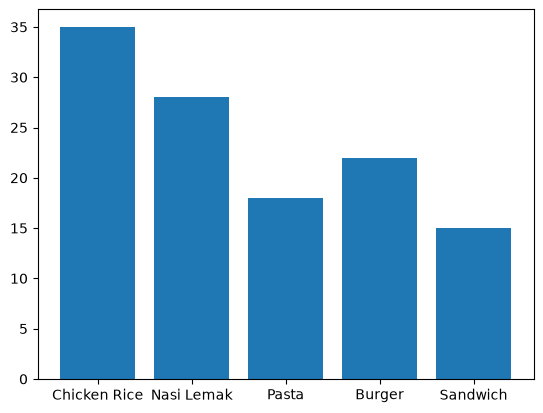

In [15]:
plt.bar(food["Food"], food["Orders"])
plt.show()

Output: A basic five-bar chart with Chicken Rice highest at 35; it does not yet have an added title or axis labels.

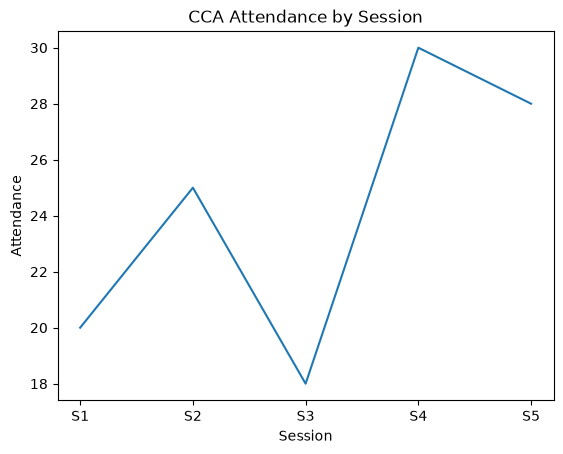

In [16]:
sessions = ["S1", "S2", "S3", "S4", "S5"]
plt.plot(sessions, attendance)
plt.title("CCA Attendance by Session")
plt.xlabel("Session")
plt.ylabel("Attendance")
plt.show()

Output: A line chart showing attendance dipping at S3, peaking at S4, and ending above S1.

In [17]:
study_data = {
    "Student": ["Alex", "Bella", "Chen", "Deepa", "Ethan"],
    "Hours Studied": [2, 4, 1, 5, 3],
    "Quiz Score": [65, 82, 58, 90, 75]
}
study = pd.DataFrame(study_data)
study

,Student,Hours Studied,Quiz Score
0,Alex,2,65
1,Bella,4,82
2,Chen,1,58
3,Deepa,5,90
4,Ethan,3,75


Output: A five-row DataFrame containing Student, Hours Studied, and Quiz Score.

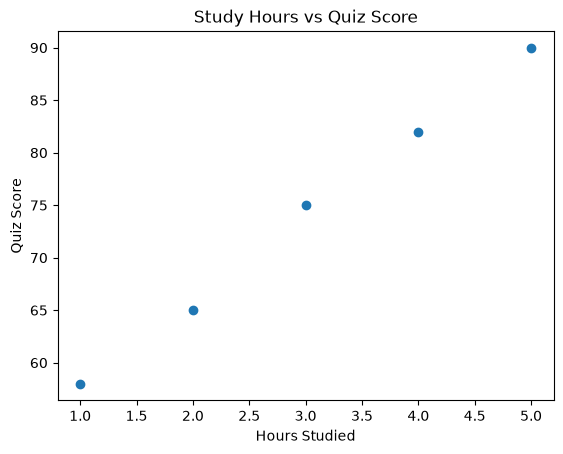

In [18]:
plt.scatter(study["Hours Studied"], study["Quiz Score"])
plt.title("Study Hours vs Quiz Score")
plt.xlabel("Hours Studied")
plt.ylabel("Quiz Score")
plt.show()

Output: A five-point scatter plot showing a positive relationship in this small sample; it does not prove that more study always causes a higher score.

### Chart interpretation recap

For each chart, identify:

1. **Title:** What question is this chart about?
2. **Axes:** What does each direction measure?
3. **Insight:** What visible pattern answers the question?

Bar charts compare categories, line charts show an ordered sequence, and scatter plots compare two numbers.

## Activity 2: Most Popular Food — Slides 27–28

**Attempt time: 6 minutes**

Create a bar chart, add the title `Food Orders`, label the axes `Food` and `Number of Orders`, identify the tallest bar, and write one insight.

Complete Cells 49 and 51. The speaker will call 2 minutes remaining.

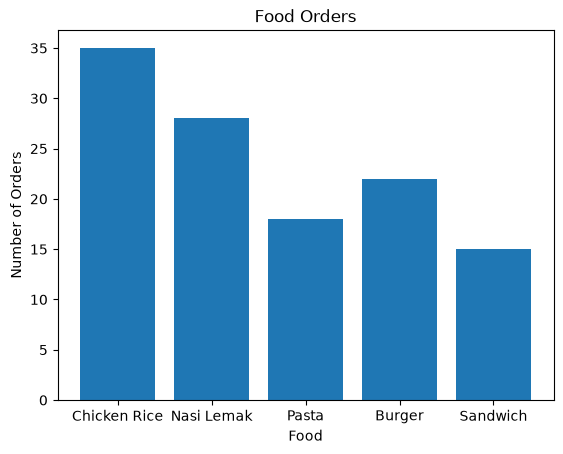

In [19]:
plt.bar(food["Food"], food["Orders"])
plt.title("Food Orders")
plt.xlabel("Food")
plt.ylabel("Number of Orders")
plt.show()

Output: A labelled five-bar chart with one clearly tallest bar.

**Possible solution — Insight:** Chicken Rice received the most orders, with 35.

<details>
<summary>Facilitator hints</summary>

- The x-axis uses `Food`.
- Bar height uses `Orders`.
- The tallest bar answers the question.

</details>

## seaborn: Cleaner Defaults — Slides 29–30

Same data, same question. matplotlib offers direct control; seaborn often gives cleaner defaults for labelled data. We will recreate only the food-orders chart, not start a separate seaborn lecture.

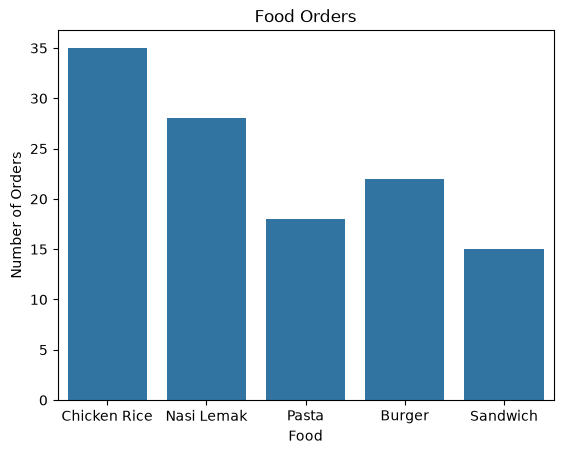

In [20]:
sns.barplot(data=food, x="Food", y="Orders")
plt.title("Food Orders")
plt.xlabel("Food")
plt.ylabel("Number of Orders")
plt.show()

Output: A cleaner-default bar chart using the same five food-order values; Chicken Rice remains highest at 35.

## Wrap-up — Slides 31–32

**Question → Data → Code → Output/Chart → Insight**

- pandas: main tool for tables.
- matplotlib: main tool for bar, line, and scatter charts.
- NumPy: light numerical support.
- seaborn: a cleaner plotting alternative.

Today we looked for patterns.
Next week, machine learning uses patterns to make predictions.

## Optional Extension — Only if time remains

Discuss these questions only after the required workshop is complete:

- Who had the highest quiz score?
- Does more study time seem related to quiz score?
- Which favourite food appears most often?

This is not part of the required 120-minute flow and must be cut first if time is short.